# MIT-BIH Atrial Fibrillation Database (AFDB) Analysis

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Dataset Path Setup

In [6]:
# UPDATE THIS PATH to your local MIT-BIH AFDB location
DATA_PATH = 'C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/data/MIT-BIH AFDB/files'  # Based on your folder structure

# Check if path exists
if os.path.exists(DATA_PATH):
    print(f"✓ Dataset path found: {DATA_PATH}")
    
    # List files
    files = os.listdir(DATA_PATH)
    print(f"\nTotal files in directory: {len(files)}")
    
    # Count file types
    file_types = {}
    for f in files:
        ext = f.split('.')[-1]
        file_types[ext] = file_types.get(ext, 0) + 1
    
    print("\nFile types:")
    for ext, count in sorted(file_types.items()):
        print(f"  .{ext}: {count} files")
else:
    print(f"✗ Dataset path not found: {DATA_PATH}")
    print("Please update the DATA_PATH variable to point to your 'files' folder")

✓ Dataset path found: C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/data/MIT-BIH AFDB/files

Total files in directory: 132

File types:
  .ANNOTATORS: 1 files
  .RECORDS: 1 files
  .atr: 25 files
  .atr-: 2 files
  .dat: 23 files
  .hea: 25 files
  .hea-: 23 files
  .old: 1 files
  .qrs: 25 files
  .qrs-: 1 files
  .qrsc: 2 files
  .txt: 2 files
  .xws: 1 files


## 2. Get List of Records

MIT-BIH AFDB uses WFDB format. Each record has multiple files:
- `.hea` - Header file (metadata)
- `.dat` - Signal data
- `.atr` - Annotation file (rhythm labels)
- `.qrs` - QRS annotations

In [7]:
def get_record_names(data_path):
    """
    Extract unique record names from .hea files
    """
    files = os.listdir(data_path)
    
    # Get all .hea files (header files)
    hea_files = [f for f in files if f.endswith('.hea')]
    
    # Extract record names (without extension)
    record_names = [f.replace('.hea', '') for f in hea_files]
    
    return sorted(record_names)

# Get all record names
record_names = get_record_names(DATA_PATH)

print(f"Found {len(record_names)} records in the dataset\n")
print("First 10 records:")
for i, name in enumerate(record_names[:10], 1):
    print(f"  {i}. {name}")

if len(record_names) > 10:
    print(f"  ... and {len(record_names) - 10} more")

Found 25 records in the dataset

First 10 records:
  1. 00735
  2. 03665
  3. 04015
  4. 04043
  5. 04048
  6. 04126
  7. 04746
  8. 04908
  9. 04936
  10. 05091
  ... and 15 more


## 3. Analyze Each Record

In [ ]:
def analyze_mitbih_record(record_name, data_path):
    """
    Analyze a single MIT-BIH AFDB record
    Returns: dict with duration, AF vs Non-AF classification based on predominant rhythm
    """
    try:
        # Read header
        record_path = os.path.join(data_path, record_name)
        header = wfdb.rdheader(record_path)
        
        # Calculate duration
        duration_sec = header.sig_len / header.fs
        duration_min = duration_sec / 60
        duration_hr = duration_sec / 3600
        
        # Read annotations (rhythm labels)
        try:
            annotation = wfdb.rdann(record_path, 'atr')
            
            # Get rhythm labels and their sample positions
            rhythm_labels = [note for note in annotation.aux_note if note]
            sample_positions = annotation.sample
            
            # Calculate duration of each rhythm type
            af_duration = 0  # AF + AFL combined
            normal_duration = 0
            other_duration = 0
            
            # Track current rhythm
            current_rhythm = None
            current_start = 0
            
            for i, (note, sample) in enumerate(zip(annotation.aux_note, sample_positions)):
                if not note:  # Skip empty annotations
                    continue
                    
                # Before switching rhythm, calculate duration of previous segment
                if current_rhythm is not None:
                    segment_duration = (sample - current_start) / header.fs
                    
                    if current_rhythm in ['AF', 'AFL']:
                        af_duration += segment_duration
                    elif current_rhythm == 'N':
                        normal_duration += segment_duration
                    else:
                        other_duration += segment_duration
                
                # Determine new rhythm
                if 'AFIB' in note.upper() or 'AFL' in note.upper():
                    current_rhythm = 'AF'
                elif note.strip() == '(N':
                    current_rhythm = 'N'
                else:
                    current_rhythm = 'Other'
                
                current_start = sample
            
            # Add the last segment (from last annotation to end of recording)
            if current_rhythm is not None:
                segment_duration = (header.sig_len - current_start) / header.fs
                
                if current_rhythm in ['AF', 'AFL']:
                    af_duration += segment_duration
                elif current_rhythm == 'N':
                    normal_duration += segment_duration
                else:
                    other_duration += segment_duration
            
            # Calculate percentages
            total_annotated = af_duration + normal_duration + other_duration
            if total_annotated > 0:
                af_percentage = (af_duration / total_annotated) * 100
                normal_percentage = (normal_duration / total_annotated) * 100
                other_percentage = (other_duration / total_annotated) * 100
            else:
                af_percentage = 0
                normal_percentage = 0
                other_percentage = 0
            
            # Classify based on predominant rhythm (>50%)
            if af_percentage >= 50:
                overall_classification = 'AF'
            elif normal_percentage >= 50:
                overall_classification = 'Non-AF'
            else:
                overall_classification = 'Mixed'
            
            # Count segments for reference
            afib_segments = sum(1 for label in rhythm_labels if 'AFIB' in label.upper())
            afl_segments = sum(1 for label in rhythm_labels if 'AFL' in label.upper())
            normal_segments = sum(1 for label in rhythm_labels if label.strip() == '(N')
            
            has_annotations = True
            
        except Exception as e:
            rhythm_labels = []
            af_duration = 0
            normal_duration = 0
            other_duration = 0
            af_percentage = 0
            normal_percentage = 0
            other_percentage = 0
            afib_segments = 0
            afl_segments = 0
            normal_segments = 0
            overall_classification = 'Unknown'
            has_annotations = False
        
        return {
            'record_name': record_name,
            'duration_sec': duration_sec,
            'duration_min': duration_min,
            'duration_hr': duration_hr,
            'sampling_rate': header.fs,
            'n_leads': header.n_sig,
            'signal_length': header.sig_len,
            'af_duration_sec': af_duration,
            'normal_duration_sec': normal_duration,
            'other_duration_sec': other_duration,
            'af_percentage': af_percentage,
            'normal_percentage': normal_percentage,
            'other_percentage': other_percentage,
            'afib_segments': afib_segments,
            'afl_segments': afl_segments,
            'normal_segments': normal_segments,
            'total_rhythm_changes': len(rhythm_labels),
            'overall_classification': overall_classification,
            'has_annotations': has_annotations
        }
        
    except Exception as e:
        print(f"Error processing {record_name}: {e}")
        return None

# Test on first record
if record_names:
    print(f"Testing analysis on record: {record_names[0]}\\n")
    sample_info = analyze_mitbih_record(record_names[0], DATA_PATH)
    
    if sample_info:
        print("Sample record information:")
        for key, value in sample_info.items():
            if 'percentage' in key:
                print(f"  {key}: {value:.2f}%")
            elif 'duration' in key and ('sec' in key or 'min' in key or 'hr' in key):
                print(f"  {key}: {value:.2f}")
            else:
                print(f"  {key}: {value}")

Testing analysis on record: 00735\n
Sample record information:
  record_name: 00735
  duration_sec: 0.00
  duration_min: 0.00
  duration_hr: 0.00
  sampling_rate: 250
  n_leads: 0
  signal_length: 0
  af_duration_sec: 264.07
  normal_duration_sec: -264.29
  other_duration_sec: 0.00
  af_percentage: 0.00%
  normal_percentage: 0.00%
  other_percentage: 0.00%
  afib_segments: 1
  afl_segments: 0
  normal_segments: 2
  total_rhythm_changes: 3
  overall_classification: Mixed
  has_annotations: True


In [10]:
# Analyze ALL records
print("Analyzing all MIT-BIH AFDB records...\n")

all_records_info = []
for i, record_name in enumerate(record_names, 1):
    print(f"Processing {i}/{len(record_names)}: {record_name}...", end=" ")
    
    info = analyze_mitbih_record(record_name, DATA_PATH)
    if info:
        all_records_info.append(info)
        print("✓")
    else:
        print("✗")

print(f"\n{'='*60}")
print(f"Successfully processed: {len(all_records_info)} / {len(record_names)} records")
print(f"{'='*60}")

# Convert to DataFrame
df_mitbih = pd.DataFrame(all_records_info)
print(f"\nDataFrame shape: {df_mitbih.shape}")
print("\nFirst few records:")
display(df_mitbih.head(25))

Analyzing all MIT-BIH AFDB records...

Processing 1/25: 00735... ✓
Processing 2/25: 03665... ✓
Processing 3/25: 04015... ✓
Processing 4/25: 04043... ✓
Processing 5/25: 04048... ✓
Processing 6/25: 04126... ✓
Processing 7/25: 04746... ✓
Processing 8/25: 04908... ✓
Processing 9/25: 04936... ✓
Processing 10/25: 05091... ✓
Processing 11/25: 05121... ✓
Processing 12/25: 05261... ✓
Processing 13/25: 06426... ✓
Processing 14/25: 06453... ✓
Processing 15/25: 06995... ✓
Processing 16/25: 07162... ✓
Processing 17/25: 07859... ✓
Processing 18/25: 07879... ✓
Processing 19/25: 07910... ✓
Processing 20/25: 08215... ✓
Processing 21/25: 08219... ✓
Processing 22/25: 08378... ✓
Processing 23/25: 08405... ✓
Processing 24/25: 08434... ✓
Processing 25/25: 08455... ✓

Successfully processed: 25 / 25 records

DataFrame shape: (25, 19)

First few records:


,record_name,duration_sec,duration_min,duration_hr,sampling_rate,n_leads,signal_length,af_duration_sec,normal_duration_sec,other_duration_sec,af_percentage,normal_percentage,other_percentage,afib_segments,afl_segments,normal_segments,total_rhythm_changes,overall_classification,has_annotations
0,00735,0.00,0.000000,0.000000,250,0,0,264.068,-264.292,0.000,0.000000,0.000000,0.000000,1,0,2,3,Mixed,True
1,03665,0.00,0.000000,0.000000,250,0,0,5959.412,11667.720,-17627.252,0.000000,0.000000,0.000000,7,0,2,15,Mixed,True
2,04015,36823.04,613.717333,10.228622,250,2,9205760,237.236,36585.684,0.000,0.644262,99.355738,0.000000,7,0,8,15,Non-AF,True
3,04043,36823.04,613.717333,10.228622,250,2,9205760,7932.604,28890.164,0.000,21.542661,78.457339,0.000000,82,1,83,166,Non-AF,True
4,04048,36823.04,613.717333,10.228622,250,2,9205760,360.776,36461.560,0.000,0.979775,99.020225,0.000000,7,0,8,15,Non-AF,True
5,04126,36823.04,613.717333,10.228622,250,2,9205760,1377.972,35444.452,0.000,3.742209,96.257791,0.000000,7,0,8,15,Non-AF,True
6,04746,36823.04,613.717333,10.228622,250,2,9205760,19553.008,17269.784,0.000,53.100286,46.899714,0.000000,5,0,6,11,AF,True
7,04908,36823.04,613.717333,10.228622,250,2,9205760,3336.068,33486.896,0.000,9.059749,90.940251,0.000000,8,4,5,17,Non-AF,True
8,04936,36823.04,613.717333,10.228622,250,2,9205760,29951.612,6871.260,0.000,81.339696,18.660304,0.000000,36,1,36,73,AF,True
9,05091,36823.04,613.717333,10.228622,250,2,9205760,86.768,36735.956,0.000,0.235637,99.764363,0.000000,8,0,9,17,Non-AF,True


## 4. KEY RESULTS: Duration, AF vs Non-AF, Amount of Records

In [ ]:
print("="*70)
print("MIT-BIH ATRIAL FIBRILLATION DATABASE (AFDB) - KEY STATISTICS")
print("="*70)

# 1. AMOUNT OF RECORDS
print(f"\n1. TOTAL NUMBER OF RECORDS: {len(df_mitbih)}")

# 2. DURATION STATISTICS
print(f"\n2. DURATION STATISTICS:")
print(f"   {'Metric':<20} {'Seconds':<15} {'Minutes':<15} {'Hours'}")
print(f"   {'-'*20} {'-'*15} {'-'*15} {'-'*15}")
print(f"   {'Mean:':<20} {df_mitbih['duration_sec'].mean():>10.1f} {df_mitbih['duration_min'].mean():>12.1f} {df_mitbih['duration_hr'].mean():>12.2f}")
print(f"   {'Median:':<20} {df_mitbih['duration_sec'].median():>10.1f} {df_mitbih['duration_min'].median():>12.1f} {df_mitbih['duration_hr'].median():>12.2f}")
print(f"   {'Min:':<20} {df_mitbih['duration_sec'].min():>10.1f} {df_mitbih['duration_min'].min():>12.1f} {df_mitbih['duration_hr'].min():>12.2f}")
print(f"   {'Max:':<20} {df_mitbih['duration_sec'].max():>10.1f} {df_mitbih['duration_min'].max():>12.1f} {df_mitbih['duration_hr'].max():>12.2f}")
print(f"   {'Total Duration:':<20} {df_mitbih['duration_sec'].sum():>10.1f} {df_mitbih['duration_min'].sum():>12.1f} {df_mitbih['duration_hr'].sum():>12.2f}")

# 3. AF VS NON-AF DISTRIBUTION
print(f"\n3. AF vs NON-AF DISTRIBUTION:")
print(f"\n   Based on predominant rhythm (>50% of recording duration):\n")

classification_counts = df_mitbih['overall_classification'].value_counts()
print(f"   {'Classification':<15} {'Count':<10} {'Percentage'}")
print(f"   {'-'*15} {'-'*10} {'-'*15}")
for classification, count in classification_counts.items():
    pct = (count / len(df_mitbih)) * 100
    print(f"   {classification:<15} {count:<10} {pct:>6.2f}%")

# Extract specific counts
af_count = classification_counts.get('AF', 0)
non_af_count = classification_counts.get('Non-AF', 0)
mixed_count = classification_counts.get('Mixed', 0)
unknown_count = classification_counts.get('Unknown', 0)

print(f"\n   Summary:")
print(f"   - AF records (>50% AF): {af_count} ({af_count/len(df_mitbih)*100:.1f}%)")
print(f"   - Non-AF records (>50% normal): {non_af_count} ({non_af_count/len(df_mitbih)*100:.1f}%)")
print(f"   - Mixed records: {mixed_count} ({mixed_count/len(df_mitbih)*100:.1f}%)")
print(f"   - Unknown: {unknown_count} ({unknown_count/len(df_mitbih)*100:.1f}%)")

if af_count > 0 and non_af_count > 0:
    ratio_af_nonaf = af_count / non_af_count
    ratio_nonaf_af = non_af_count / af_count
    print(f"\n   Class ratio (AF:Non-AF) = {ratio_af_nonaf:.2f}:1")
    print(f"   Class ratio (Non-AF:AF) = {ratio_nonaf_af:.2f}:1")

# 4. Average AF content per record
print(f"\n4. AF CONTENT ANALYSIS:")
print(f"   Mean AF percentage per record: {df_mitbih['af_percentage'].mean():.1f}%")
print(f"   Median AF percentage per record: {df_mitbih['af_percentage'].median():.1f}%")
print(f"   Mean Normal percentage per record: {df_mitbih['normal_percentage'].mean():.1f}%")
print(f"   Median Normal percentage per record: {df_mitbih['normal_percentage'].median():.1f}%")

# Additional info
print(f"\n5. ADDITIONAL INFORMATION:")
print(f"   - Sampling rate(s): {df_mitbih['sampling_rate'].unique()} Hz")
print(f"   - Number of leads: {df_mitbih['n_leads'].unique()}")
print(f"   - Records with annotations: {df_mitbih['has_annotations'].sum()} ({df_mitbih['has_annotations'].sum()/len(df_mitbih)*100:.1f}%)")

print(f"\n{'='*70}")

MIT-BIH ATRIAL FIBRILLATION DATABASE (AFDB) - KEY STATISTICS

1. TOTAL NUMBER OF RECORDS: 25

2. DURATION STATISTICS:
   Metric               Seconds         Minutes         Hours
   -------------------- --------------- --------------- ---------------
   Mean:                   33736.3        562.3         9.37
   Median:                 36823.0        613.7        10.23
   Min:                        0.0          0.0         0.00
   Max:                    36823.0        613.7        10.23
   Total Duration:        843406.9      14056.8       234.28

3. AF vs NON-AF DISTRIBUTION:

   Based on predominant rhythm (>50% of recording duration):

   Classification  Count      Percentage
   --------------- ---------- ---------------
   Non-AF          13          52.00%
   AF              10          40.00%
   Mixed           2            8.00%

   Summary:
   - AF records (>50% AF): 10 (40.0%)
   - Non-AF records (>50% normal): 13 (52.0%)
   - Mixed records: 2 (8.0%)
   - Unknown: 0 (0.0%)

## 5. Visualizations

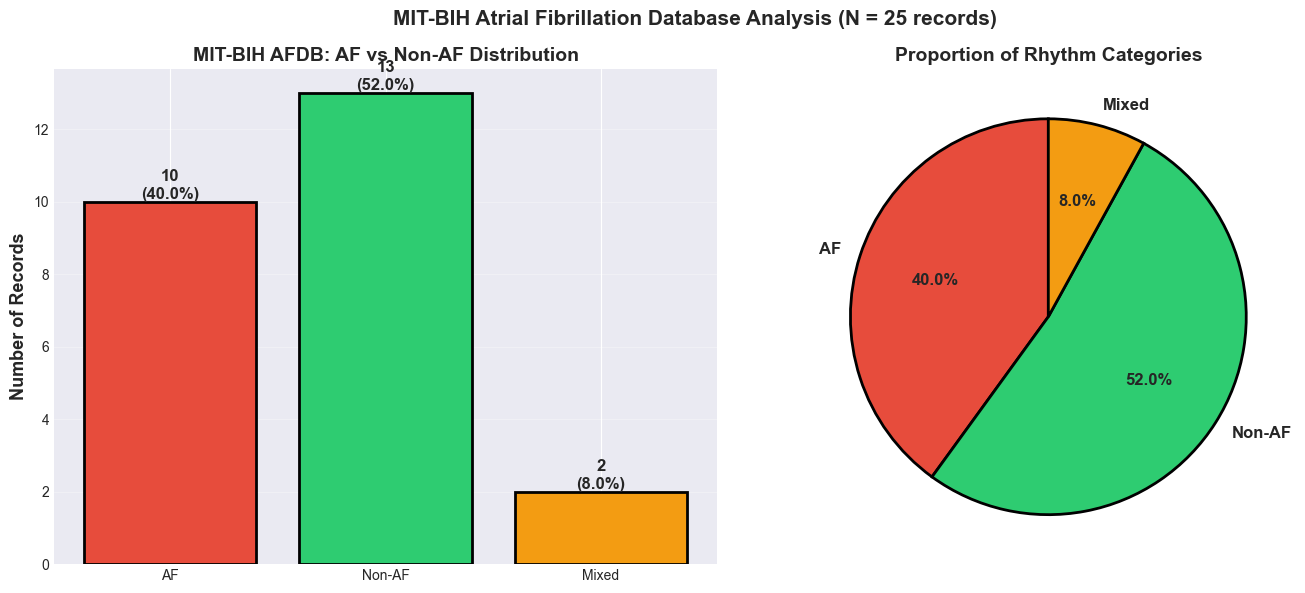

✓ Visualization saved as 'mitbih_afdb_analysis.png'


In [38]:
# Create visualization with just bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. AF vs Non-AF Bar Chart
ax1 = axes[0]
categories = ['AF', 'Non-AF', 'Mixed']
counts = [af_count, non_af_count, mixed_count]
colors_bar = ['#e74c3c', '#2ecc71', '#f39c12']
bars = ax1.bar(categories, counts, color=colors_bar, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Records', fontsize=13, fontweight='bold')
ax1.set_title('MIT-BIH AFDB: AF vs Non-AF Distribution', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}\n({count/len(df_mitbih)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Pie Chart  
ax2 = axes[1]
# Only show non-zero categories
pie_categories = [cat for cat, cnt in zip(categories, counts) if cnt > 0]
pie_counts = [cnt for cnt in counts if cnt > 0]
pie_colors = [color for color, cnt in zip(colors_bar, counts) if cnt > 0]

if len(pie_counts) > 0:
    ax2.pie(pie_counts, labels=pie_categories, autopct='%1.1f%%', colors=pie_colors,
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    ax2.set_title('Proportion of Rhythm Categories', fontsize=14, fontweight='bold')

plt.suptitle(f'MIT-BIH Atrial Fibrillation Database Analysis (N = {len(df_mitbih)} records)',
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/notebooks/plots/mitbih_afdb_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'mitbih_afdb_analysis.png'")

## 6. Detailed Duration Analysis

In [35]:
# Create a detailed duration table
print("\nDETAILED DURATION BY RECORD:\n")
duration_table = df_mitbih[['record_name', 'overall_classification', 'duration_hr', 
                            'duration_min', 'afib_segments', 'normal_segments']].copy()
duration_table = duration_table.sort_values('duration_hr', ascending=False)
duration_table['duration_hr'] = duration_table['duration_hr'].round(2)
duration_table['duration_min'] = duration_table['duration_min'].round(1)

display(duration_table)


DETAILED DURATION BY RECORD:



,record_name,overall_classification,duration_hr,duration_min,afib_segments,normal_segments
12,06426,AF,10.23,613.7,26,23
14,06995,Non-AF,10.23,613.7,6,3
23,08434,Non-AF,10.23,613.7,3,4
22,08405,AF,10.23,613.7,2,2
21,08378,Non-AF,10.23,613.7,5,9
20,08219,Non-AF,10.23,613.7,39,40
19,08215,AF,10.23,613.7,2,1
18,07910,Non-AF,10.23,613.7,5,4
17,07879,AF,10.23,613.7,2,2
16,07859,AF,10.23,613.7,1,0


## 7. Summary Table for Thesis

In [37]:
# Create a clean summary table for your thesis
summary_data = {
    'Metric': [
        'Total Number of Records',
        'AF Records',
        'Non-AF Records',
        'Mixed Records',
        '',
        'Mean Duration per Record',
        'Median Duration per Record',
        'Min Duration',
        'Max Duration',
        'Total Dataset Duration',
        '',
        'Sampling Rate',
        'Number of Leads',
        'Records with Annotations'
    ],
    'Value': [
        f"{len(df_mitbih)}",
        f"{af_count} ({af_count/len(df_mitbih)*100:.1f}%)",
        f"{non_af_count} ({non_af_count/len(df_mitbih)*100:.1f}%)",
        f"{mixed_count} ({mixed_count/len(df_mitbih)*100:.1f}%)",
        '',
        f"{df_mitbih['duration_hr'].mean():.2f} hours ({df_mitbih['duration_min'].mean():.1f} min)",
        f"{df_mitbih['duration_hr'].median():.2f} hours ({df_mitbih['duration_min'].median():.1f} min)",
        f"{df_mitbih['duration_hr'].min():.2f} hours ({df_mitbih['duration_min'].min():.1f} min)",
        f"{df_mitbih['duration_hr'].max():.2f} hours ({df_mitbih['duration_min'].max():.1f} min)",
        f"{df_mitbih['duration_hr'].sum():.2f} hours ({df_mitbih['duration_min'].sum():.1f} min)",
        '',
        f"{int(df_mitbih['sampling_rate'].mode()[0])} Hz",
        f"{int(df_mitbih['n_leads'].mode()[0])}",
        f"{df_mitbih['has_annotations'].sum()} ({df_mitbih['has_annotations'].sum()/len(df_mitbih)*100:.1f}%)"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("MIT-BIH AFDB SUMMARY TABLE (FOR THESIS)")
print("="*70)
display(summary_df)

# Save to CSV
summary_df.to_csv('C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/notebooks/csv/mitbih_afdb_summary.csv', index=False)
print("\n✓ Summary table saved as 'mitbih_afdb_summary.csv'")


MIT-BIH AFDB SUMMARY TABLE (FOR THESIS)


,Metric,Value
0,Total Number of Records,25
1,AF Records,10 (40.0%)
2,Non-AF Records,13 (52.0%)
3,Mixed Records,2 (8.0%)
4,,
5,Mean Duration per Record,9.37 hours (562.3 min)
6,Median Duration per Record,10.23 hours (613.7 min)
7,Min Duration,0.00 hours (0.0 min)
8,Max Duration,10.23 hours (613.7 min)
9,Total Dataset Duration,234.28 hours (14056.8 min)



✓ Summary table saved as 'mitbih_afdb_summary.csv'
